Imports and Initiallization

In [1]:
#Log in to huggingface hub
from huggingface_hub import login
import os
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, logging
import torch
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
load_dotenv()
login(token = os.getenv("HFToken"))
model_id = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id,padding_side="left")
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="cuda:0",dtype=torch.bfloat16)
ds = load_dataset("rajpurkar/squad")
logging.set_verbosity_info()
#HFToken = [your token] in .env

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

In [2]:
""" Official evaluation script for v1.1 of the SQuAD dataset. """

import re
import string
from collections import Counter


def normalize_answer(s):
    """Lower text and remove punctuation, articles and extra whitespace."""

    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def white_space_fix(text):
        return " ".join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))


def f1_score(prediction, ground_truth):
    prediction_tokens = normalize_answer(prediction).split()
    ground_truth_tokens = normalize_answer(ground_truth).split()
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0
    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

In [3]:
def plot(x,y,title,xl,yl):
    slope, intercept = np.polyfit(x,y,1)
    plt.suptitle(title)
    plt.xlabel(xl)
    plt.ylabel(yl)
    plt.xlim(min(x),max(y))
    plt.ylim(min(y)-0.01,max(y)+0.01)
    x = np.linspace(0,1,100)
    y = slope*x+intercept
    plt.plot(x,y)
    plt.plot(confidence,f1,'ro',alpha=0.5)

In [4]:
#Prompt Generation
prompt = [[
    {
        "role": "system",
        "content":"Answer in as few words as possible. Output only the entity name and nothing else."
        #"content": "You are a precise calculator. Output ONLY the final numerical answer. Do not include words, units, explanations, or punctuation."
    },
    {
        "role": "user",
        "content":  f"Context:\n{context}\n\nQuestion:\n{question}"
    }
]for context,question in zip(ds["train"]["context"],ds["train"]["question"])]
def input_Batch(batch,questions):
    input = tokenizer.apply_chat_template(
        prompt[(batch*questions):((batch+1)*questions)],
        tokenize = True,
        add_generation_prompt=True,
        padding=True,
        return_tensors="pt",
        clean_up_tokenization_spaces=False
    ).to("cuda:0")
    input_length = input["input_ids"].shape[1]
    return(input,input_length)



In [5]:
#Output Saving
def output_Batch(input):
    raw_output = model.generate(
        **input,
        max_new_tokens= 100,
        do_sample=False,
        temperature=1,
        pad_token_id=tokenizer.pad_token_id,
        tokenizer=tokenizer,
        return_dict_in_generate=True,
        output_logits=True,
        output_scores=True
        )
    output = raw_output.sequences
    return(output,raw_output)
#for i in range(questions):
 #   write.append(tokenizer.decode(output[i][input_length:],skip_special_tokens=True))
#json.dump(write,f)

In [6]:
#f1 data
def f1_batch(output,input_length,questions):
    predictions = []
    for i in range(questions):
       predictions.append(tokenizer.decode(output[i][input_length:],skip_special_tokens=True,clean_up_tokenization_spaces=True))
    f1 = torch.zeros(questions)
    for i in range(questions):
        f1[i] = f1_score(predictions[i],ds["train"]["answers"][i]["text"][0])
    f1 = f1.cpu()
    return(f1)

In [7]:
#confidence calculation
def logits_batch(raw_output,questions):
    logits = raw_output.scores[-50:]
    tensor_logits = torch.stack(logits)
    prob = tensor_logits.softmax(dim=2)
    confidence = torch.zeros(questions)
    max_prob, max_ids = torch.max(prob,dim=2)
    confidence = torch.prod(max_prob,dim=0).cpu()
    return(confidence)

In [8]:
def process_Batch(batch,size):
    input,input_length = input_Batch(batch,size)
    output, raw_output = output_Batch(input)
    f1 = f1_batch(output,input_length,size)
    confidence = logits_batch(raw_output,size)
    return(confidence,f1)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


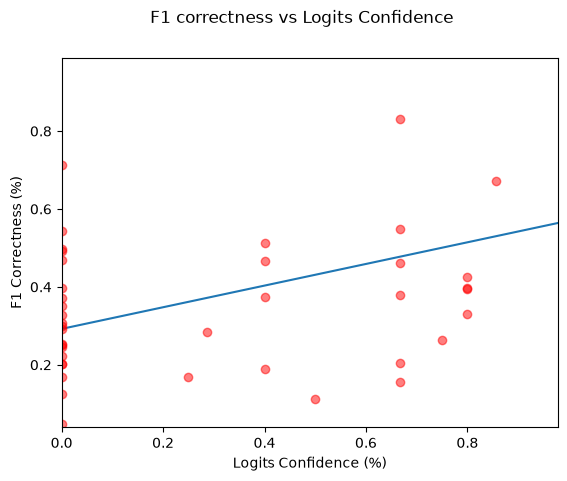

In [9]:
confidence,f1 = process_Batch(0,100)
plot(confidence,f1,'F1 correctness vs Logits Confidence','Logits Confidence (%)','F1 Correctness (%)')